In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, log_loss
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV


file_path = '/content/drive/MyDrive/Sreports_dse/dse_market_stress.csv'  # Update with the correct path
df = pd.read_csv(file_path)

# Features (all columns except the target)
X = df[['daily_return', 'high_low_spread', 'intraday_volatility', 'volume_change_pct', 'price_gap',
        'rolling_5_day_volatility', 'rolling_10_day_momentum']]  # Same feature list as your notebook

# Convert features to float32 for efficiency
X = X.astype(np.float32)

# Target variable (market type)
y = df['market_type']

# Label encoding if necessary (market type classes: 0 = Normal, 1 = High Volatility, 2 = Crash)
le = LabelEncoder()
y = le.fit_transform(y)

# Convert target variable to float32 (if needed)
y = y.astype(np.float32)

In [ ]:
# Check for inf and NaN values in the dataset
print("Number of Infinite values in each column:\n", np.isinf(X).sum())
print("Number of NaN values in each column:\n", X.isna().sum())

Number of Infinite values in each column:
 daily_return                    0
high_low_spread                 0
intraday_volatility          1153
volume_change_pct           20614
price_gap                       0
rolling_5_day_volatility        0
rolling_10_day_momentum         0
dtype: int64
Number of NaN values in each column:
 daily_return                0
high_low_spread             0
intraday_volatility         0
volume_change_pct           0
price_gap                   0
rolling_5_day_volatility    0
rolling_10_day_momentum     0
dtype: int64


In [ ]:
# Replace inf with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaN values (or you can use imputation methods)
X.dropna(inplace=True)
y = y[X.index]  # Ensure the target variable aligns with the dropped rows

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 6, 10],
    "min_samples_split": [2, 5, 10]
}

In [ ]:

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Calculate total number of fits (n_iter * cv)
total_fits = 5 * 3  # n_iter=5, cv=3

print(f"\nRandomizedSearchCV settings:")
print(f"n_iter: 5")
print(f"cv folds: 3")
print(f"Total fits: {total_fits}\n")
print("Starting Randomized Search...\n")

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=5,
    scoring='accuracy',
    cv=3,
    verbose=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("\nRandomized Search Completed!")
print("Best Hyperparameters from RandomizedSearchCV: ", random_search.best_params_)


RandomizedSearchCV settings:
n_iter: 5
cv folds: 3
Total fits: 15

Starting Randomized Search...

Fitting 3 folds for each of 5 candidates, totalling 15 fits

Randomized Search Completed!
Best Hyperparameters from RandomizedSearchCV:  {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 3}



Classification Report (Random Forest):
               precision    recall  f1-score   support

         0.0   0.999944  0.999920  0.999932    161997
         1.0   1.000000  0.999788  0.999894     51969
         2.0   0.971098  1.000000  0.985337       504

    accuracy                       0.999888    214470
   macro avg   0.990348  0.999903  0.995054    214470
weighted avg   0.999890  0.999888  0.999889    214470



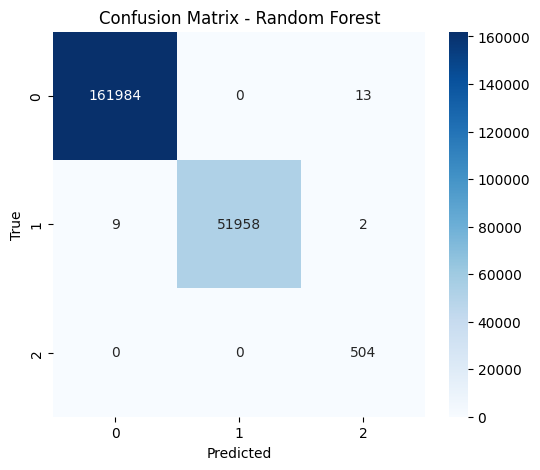

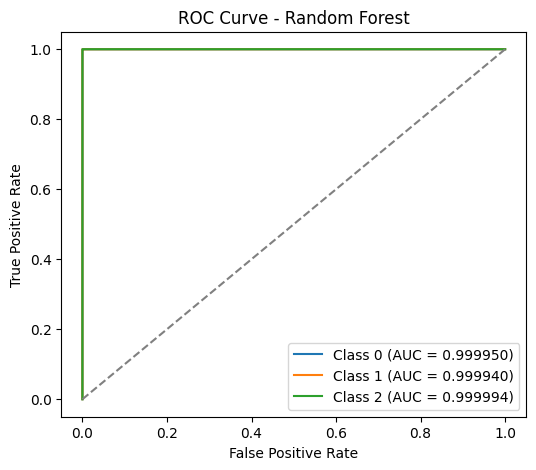

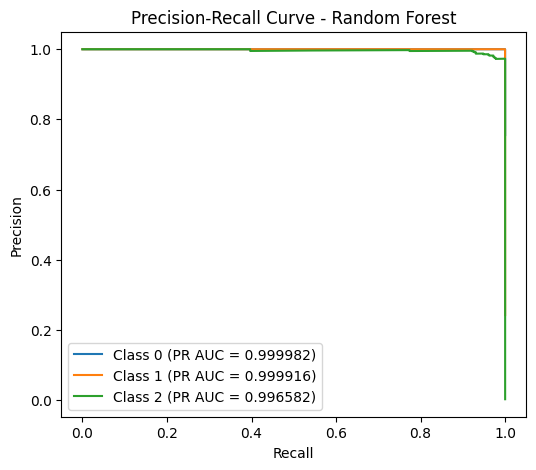

In [11]:

best_model = random_search.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test)

# Print Classification Report
print("\nClassification Report (Random Forest):\n", classification_report(y_test, y_pred, digits=6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve and AUC (multiclass one-vs-rest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(y_train).astype(int)
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_bin = best_model.predict_proba(X_test)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6, 5))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.6f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve - Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall Curve and PR AUC (multiclass one-vs-rest)
from sklearn.metrics import precision_recall_curve, auc

precision, recall, pr_auc = {}, {}, {}
for i in range(len(classes)):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred_bin[:, i])
    pr_auc[i] = auc(recall[i], precision[i])

plt.figure(figsize=(6, 5))
for i in range(len(classes)):
    plt.plot(recall[i], precision[i], label=f'Class {i} (PR AUC = {pr_auc[i]:.6f})')

plt.title('Precision-Recall Curve - Random Forest')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()

In [ ]:

from sklearn.model_selection import cross_validate

best_model = random_search.best_estimator_

# Define scoring metrics
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'neg_log_loss']

# Perform 3-fold cross validation
cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=3,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print("\n===== Cross Validation Report (3-Fold) =====\n")

for metric in scoring:
    scores = cv_results[f'test_{metric}']

    if metric == 'neg_log_loss':
        scores = -scores  # convert back to positive log loss

    print(f"{metric.replace('neg_', '')}: {scores.mean():.4f} ± {scores.std():.4f}")


===== Cross Validation Report (3-Fold) =====

accuracy: 0.9999 ± 0.0000
precision_macro: 0.9900 ± 0.0012
recall_macro: 0.9999 ± 0.0000
f1_macro: 0.9949 ± 0.0006
log_loss: 0.1946 ± 0.0029


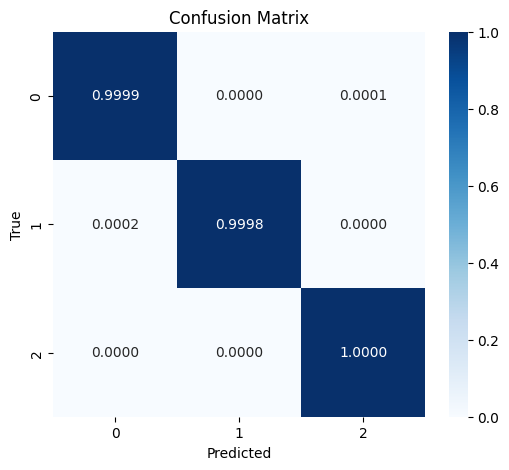

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Normalize the confusion matrix (by row sums)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot the normalized confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, fmt='.4f', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:

import os
import json
import joblib
from datetime import datetime
import numpy as np

# Folder name
SAVE_DIR = "random_forest_dse_model"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save Trained Model
joblib.dump(best_model, os.path.join(SAVE_DIR, "random_forest_model.pkl"))

# Save Label Encoder
joblib.dump(le, os.path.join(SAVE_DIR, "label_encoder.pkl"))

# Save Feature Columns
feature_info = {"feature_columns": list(X.columns)}
with open(os.path.join(SAVE_DIR, "feature_columns.json"), "w") as f:
    json.dump(feature_info, f, indent=4)

# Save Best Hyperparameters (make sure they are JSON-serializable)
best_params = {}
for k, v in random_search.best_params_.items():
    if isinstance(v, (np.integer, np.int64, np.int32)):
        v = int(v)
    elif isinstance(v, (np.floating, np.float64, np.float32)):
        v = float(v)
    best_params[str(k)] = v

with open(os.path.join(SAVE_DIR, "best_params.json"), "w") as f:
    json.dump(best_params, f, indent=4)

# Save Cross Validation Results (Mean ± Std)
cv_summary = {}
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    if metric == "neg_log_loss":
        scores = -scores
        metric_name = "log_loss"
    else:
        metric_name = metric

    cv_summary[str(metric_name)] = {
        "mean": float(np.mean(scores)),
        "std": float(np.std(scores))
    }

with open(os.path.join(SAVE_DIR, "cv_results.json"), "w") as f:
    json.dump(cv_summary, f, indent=4)

# Save Metadata (FIX: convert mapping keys to str and values to int)
class_mapping = {}
for cls_name, cls_id in zip(le.classes_, le.transform(le.classes_)):
    class_mapping[str(cls_name)] = int(cls_id)   # keys=str, values=int

metadata = {
    "model_type": "RandomForestClassifier",
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset_shape": {
        "X_train": [int(X_train.shape[0]), int(X_train.shape[1])],
        "X_test": [int(X_test.shape[0]), int(X_test.shape[1])]
    },
    "class_mapping": class_mapping,
    "random_state": 42
}

with open(os.path.join(SAVE_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

print(f"\n✅ Model package saved successfully in folder: {SAVE_DIR}")


✅ Model package saved successfully in folder: random_forest_dse_model
